# Tests Statistiques : Box-Muller
Vérification de la distribution normale (gaussienne) générée par la transformée.

In [1]:
import sys
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chisquare

sys.path.append(os.path.abspath('../generators'))
from box_muller import box_muller

N = 50000
data_bm = []

for _ in range(N // 2):
    z0, z1 = box_muller()
    data_bm.extend([z0, z1])

print(f"Génération terminée : {len(data_bm)} échantillons produits.")

Génération terminée : 50000 échantillons produits.


## 1. Validation Visuelle (Loi Normale)

Ici, nous ne cherchons pas une ligne plate. Nous vérifions si l'histogramme de nos données 
correspond à la courbe de densité théorique de la loi normale.

<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_5878/2822041777.py:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.plot(x, norm.pdf(x), 'r-', lw=2, label='Normale théorique $\mathcal{N}(0,1)$')


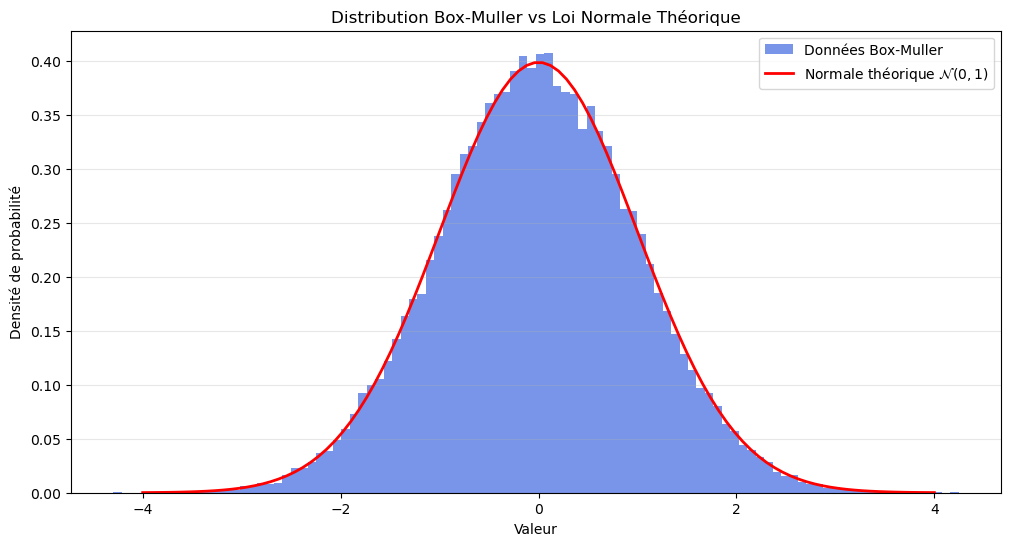

In [2]:
plt.figure(figsize=(12, 6))

count, bins, ignored = plt.hist(data_bm, bins=100, density=True, color='royalblue', alpha=0.7, label='Données Box-Muller')

x = np.linspace(-4, 4, 100)
plt.plot(x, norm.pdf(x), 'r-', lw=2, label='Normale théorique $\mathcal{N}(0,1)$')

plt.title("Distribution Box-Muller vs Loi Normale Théorique")
plt.xlabel("Valeur")
plt.ylabel("Densité de probabilité")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 2. Analyse de l'Entropie



In [3]:
def calculate_entropy_discretized(data, bins=256):
    counts, _ = np.histogram(data, bins=bins)
    probs = counts / len(data)
    probs = probs[probs > 0] # On évite log(0)
    return -np.sum(probs * np.log2(probs))

entropy_val = calculate_entropy_discretized(data_bm)
print(f"Entropie (discrétisée sur 256 bins) : {entropy_val:.5f} bits")

Entropie (discrétisée sur 256 bins) : 6.94425 bits


## 3. Test du $\chi^2$ (Chi-carré d'uniformité)



In [4]:
obs, _ = np.histogram(data_bm, bins=256)
stat, p_value = chisquare(obs)

print(f"P-value du test d'uniformité : {p_value:.5e}")

if p_value < 0.05:
    print("Verdict : L'uniformité est rejetée. C'est le résultat attendu pour Box-Muller.")
else:
    print("Verdict : Échec inattendu (les données semblent uniformes).")

P-value du test d'uniformité : 0.00000e+00
Verdict : L'uniformité est rejetée. C'est le résultat attendu pour Box-Muller.


## 4. Analyse de l'Autocorrélation


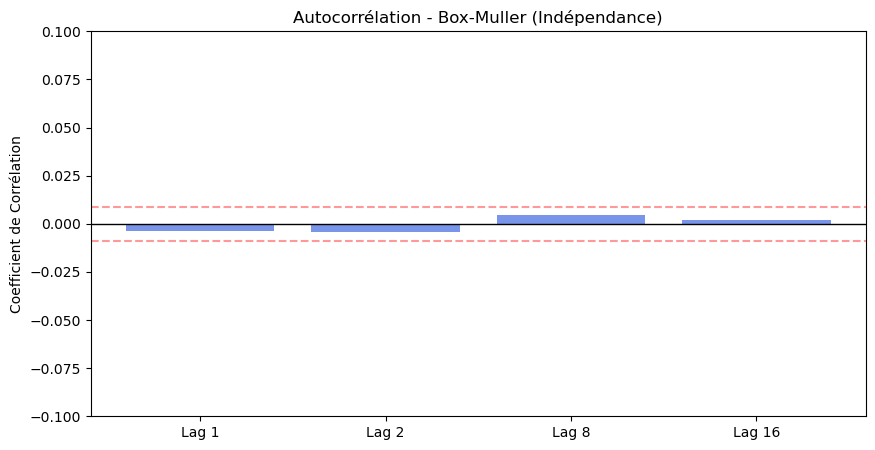

Lag 1 : -0.003866
Lag 2 : -0.004041
Lag 8 : 0.004653
Lag 16 : 0.002038


In [5]:
def plot_autocorr_bm(data, lags=[1, 2, 8, 16]):
    corrs = [np.corrcoef(data[:-lag], data[lag:])[0, 1] for lag in lags]
    
    plt.figure(figsize=(10, 5))
    plt.bar([f"Lag {l}" for l in lags], corrs, color='royalblue', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    plt.axhline(y=1.96/np.sqrt(len(data)), color='red', linestyle='--', alpha=0.4)
    plt.axhline(y=-1.96/np.sqrt(len(data)), color='red', linestyle='--', alpha=0.4)
    
    plt.title("Autocorrélation - Box-Muller (Indépendance)")
    plt.ylabel("Coefficient de Corrélation")
    plt.ylim(-0.1, 0.1)
    plt.show()

    for l, c in zip(lags, corrs):
        print(f"Lag {l} : {c:.6f}")

plot_autocorr_bm(data_bm)

## 4. Test de Kolmogorov-Smirnov (Loi Normale)


In [6]:
from scipy.stats import kstest

statistic_ks, p_value_ks = kstest(data_bm, 'norm')

print(f"Statistique KS : {statistic_ks:.5f}")
print(f"P-value KS : {p_value_ks:.5f}")

if p_value_ks > 0.05:
    print("\nVerdict : La distribution suit parfaitement une loi normale (Succès).")
else:
    print("\nVerdict : Écart significatif par rapport à la loi normale (Échec).")

Statistique KS : 0.00598
P-value KS : 0.05601

Verdict : La distribution suit parfaitement une loi normale (Succès).
